In [608]:
import torch
import numpy as np

In [609]:
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import degree
from collections import Counter
import matplotlib.pyplot as plt

import xarray as xr
import geopandas as gpd
import hvplot.pandas
import hvplot.xarray

import networkx as nx

from pathlib import Path

import os 
from torch_geometric.utils import from_networkx

In [2304]:
from torch_geometric.utils import degree
from collections import Counter

In [2373]:
os.environ["PATH"]

'/home/iacopo/.local/build/mambaforge/bin:/home/iacopo/.local/build/mambaforge/condabin:/home/iacopo/.cargo/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin:/home/iacopo/.cabal/bin:/home/iacopo/.ghcup/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin'

In [2374]:
os.environ["PATH"] += ':/home/iacopo/.local/build/mambaforge/envs/graphs/bin'
os.environ["PATH"]

'/home/iacopo/.local/build/mambaforge/bin:/home/iacopo/.local/build/mambaforge/condabin:/home/iacopo/.cargo/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin:/home/iacopo/.cabal/bin:/home/iacopo/.ghcup/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin:/home/iacopo/.local/build/mambaforge/envs/graphs/bin'

In [2532]:
# explore hydro
g = nx.read_graphml("land_graph.ml")

In [2533]:
dynamic_names = ["precip", "pet", "temp"]
static_names = [ 'thetaS', 'thetaR', 'RootingDepth', 'Swood','KsatVer'] #, 'TT', 'KsatHorFrac'] 
target_names = [ "vwc","actevap" ] # "q_river"]

fn_forcings =  "forcings.nc"  # 'inmaps_eobs_eobsd_makkink_86400_2015_2019.nc' 
fn_params = "staticmaps.nc"
fn_targets = "output.nc"


timeslice = slice("2016-01-01","2020-12-31")

In [2534]:
wflow_model = "wflow" #"adg1km_eobs" #"datademo" # "alps1km_eobs" # "alps1km_cerra", 

fn_forcings =  "forcings.nc"  # 'inmaps_eobs_eobsd_makkink_86400_2015_2019.nc' 
fn_params = "staticmaps.nc"
fn_targets = "output.nc"


fn_basins = "basins.geojson"
fn_rivers = "rivers.geojson"



wd = Path("../../data") / wflow_model

fp_dynamic_forcings = wd / fn_forcings 
fp_wflow_static_params = wd / fn_params
fp_target = wd / "run_default" / fn_targets

fp_basins = wd / "staticgeoms" / fn_basins
fp_rivers = wd / "staticgeoms" / fn_rivers

basins = gpd.read_file(fp_basins)
rivers = gpd.read_file(fp_rivers)


forcings = xr.open_dataset(fp_dynamic_forcings)
params = xr.open_dataset(fp_wflow_static_params)
targets = xr.open_dataset(fp_target).isel(lat=slice(None, None, -1))

In [2535]:
try:
    forcings = forcings.rename({"latitude":"lat", "longitude":"lon"})
    params = params.rename({"latitude":"lat", "longitude":"lon"})
except:
    pass

In [2536]:
targets.data_vars

Data variables:
    ssf      (time, lat, lon) float32 1MB ...
    actevap  (time, lat, lon) float32 1MB ...
    q_land   (time, lat, lon) float32 1MB ...
    q_river  (time, lat, lon) float32 1MB ...
    vwc      (time, layer, lat, lon) float32 6MB ...

In [2537]:
params["precip"] =  forcings.precip.isel(time=200)
params["pet"] =  forcings.pet.isel(time=200)
params["q_river"] =  targets.q_river.isel(time=199)
params["q_river_1"] =  targets.q_river.isel(time=198)

In [2538]:
var = ["wflow_dem", "KsatVer", "N", "thetaS", "thetaR","RootingDepth","Slope","precip","pet"]

In [2539]:
try:
    values = params[var]
except:
    values = params[var].sel(layer=0,drop=True)
values

<xarray.Dataset> Size: 43kB
Dimensions:       (lat: 29, lon: 33)
Coordinates:
  * lat           (lat) float64 232B 46.6 46.59 46.58 ... 46.36 46.35 46.34
  * lon           (lon) float64 264B 11.2 11.21 11.22 ... 11.48 11.48 11.49
    spatial_ref   int64 8B ...
Data variables:
    wflow_dem     (lat, lon) float32 4kB ...
    KsatVer       (lat, lon) float32 4kB ...
    N             (lat, lon) float64 8kB ...
    thetaS        (lat, lon) float32 4kB ...
    thetaR        (lat, lon) float32 4kB ...
    RootingDepth  (lat, lon) float64 8kB ...
    Slope         (lat, lon) float32 4kB ...
    precip        (lat, lon) float32 4kB ...
    pet           (lat, lon) float32 4kB ...

In [2540]:
values.dtypes

Frozen({'wflow_dem': dtype('float32'), 'KsatVer': dtype('float32'), 'N': dtype('float64'), 'thetaS': dtype('float32'), 'thetaR': dtype('float32'), 'RootingDepth': dtype('float64'), 'Slope': dtype('float32'), 'precip': dtype('float32'), 'pet': dtype('float32')})

In [2541]:
arr = []
for r in range(values[var[0]].shape[0]-1,-1,-1):
    for c in range(values[var[0]].shape[1]):
        vv = []
        for iv in var:
            v = values[iv].values[r,c]
            if ~np.isnan(v):
                 vv.append(v)
            elif np.isnan(v) and "q_river" in iv and len(vv)>0:
                vv.append(0)
            else:
                continue
        if len(vv) > 0:        
            arr.append(vv)

In [2542]:
arr[:2]

[[2142.4587,
  993.5897,
  0.26621606012723475,
  0.48946851,
  0.13947,
  243.14309872629784,
  30.39497,
  0.0,
  4.46],
 [1966.4,
  937.29364,
  0.28816148510758116,
  0.48024797,
  0.13788202,
  223.526007721911,
  17.696093,
  0.0,
  4.53]]

In [2543]:
mappi = {}
for i,n in enumerate(g.nodes()):
    g.add_node(n, elevation=arr[i])
    mappi[n] = arr[i]

In [2544]:
arr = np.array(arr).astype(np.float32)
arr.shape

(730, 9)

In [2545]:
arr = torch.Tensor(arr).type(torch.FloatTensor)

In [2546]:
arr.dtype

torch.float32

In [2547]:
rgraph = from_networkx(g,group_node_attrs= {"elevation":arr})

In [2548]:
rgraph.node_attrs()

['x']

In [2549]:
rgraph.x = rgraph.x.type(torch.FloatTensor)

In [2618]:
vartar = ["vwc"]

In [2619]:
try:
    values = targets[vartar].isel(time=200).isel(layer=0)
except:
    values = targets[vartar].isel(time=200)

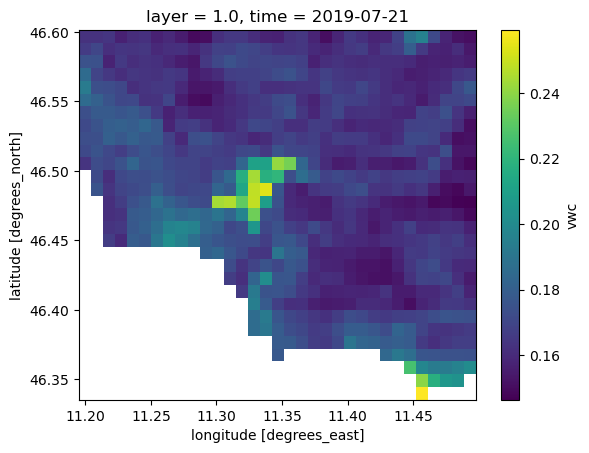

In [2620]:
values[vartar[0]].plot()

In [2621]:
arr = []
for r in range(values[vartar[0]].shape[0]-1,-1,-1):
    for c in range(values[vartar[0]].shape[1]):
        vv = []
        for iv in vartar:
            v = values[iv].values[r,c]
            if ~np.isnan(v):
                vv.append(v)
            elif np.isnan(v) and iv == "q_river" and len(vv)>0:
                vv.append(0)
            else:
                continue
        if len(vv) > 0:        
            arr.append(vv)

In [2622]:
torch.tensor(arr).dtype

torch.float32

In [2623]:
rgraph.y = torch.tensor(arr)

In [2624]:
rgraph.x.max(dim=0).values

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [2625]:
rgraph.x = (rgraph.x - rgraph.x.min(dim=0).values)/( rgraph.x.max(dim=0).values - rgraph.x.min(dim=0).values)

In [2626]:
rgraph.y = (rgraph.y - rgraph.y.min(dim=0).values)/( rgraph.y.max(dim=0).values - rgraph.y.min(dim=0).values)

In [2627]:
rgraph.x.shape,rgraph.y[:2]

(torch.Size([730, 9]),
 tensor([[1.0000],
         [0.8273]]))

In [2628]:
rgraph

Data(edge_index=[2, 718], id=[718], x=[730, 9], y=[730, 1], train_mask=[730], val_mask=[730], test_mask=[730])

In [2629]:
ncells = params.wflow_dem.shape[0]*params.wflow_dem.shape[1]  - np.sum(np.isnan(params.wflow_dem))
int(ncells)

/home/iacopo/.local/build/mambaforge/envs/graphs/lib/python3.10/site-packages/IPython/core/displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


730

In [2630]:
rgraph.num_nodes

730

In [2631]:
type(rgraph)

torch_geometric.data.data.Data

In [2632]:
from torch_geometric.transforms import BaseTransform
import torch_geometric.transforms as T

class Add_Node_Feature(BaseTransform):
    def __init__(self, parameters):
        self.paramters= paramters  # parameters you need
    def __call__(self, data):
        node_feature = data.x
        data.x = do_something(node_feature)
        return data

In [2633]:
#= T.Compose([Add_Node_Feature()])

https://networkx.org/documentation/latest/auto_examples/index.html

In [2634]:
# import matplotlib.pyplot as plt
# # create number for each group to allow use of colormap
# from itertools import count
# # get unique groups
# elev = set(nx.get_node_attributes(g,'elevation').values())
# mapping = dict(zip(sorted(elev),sorted(elev)))
# nodes = g.nodes()
# colors = [mapping[g.nodes[n]['elevation']] for n in nodes]

In [2635]:
# plt.figure(figsize=(20,20))

# pos = nx.nx_agraph.graphviz_layout(g, prog="dot")
# #pos = nx.spring_layout(g, k=10)
# options = {
#     "font_size": 6,
#     "font_color": "white",
#     "node_size": 200,
#     "node_color": "blue",
#     "edgecolors": "gray",
#     "linewidths": 1,
#     "width": 1
# }



# #options = {"edgecolors": "tab:gray", "node_size": 800, "alpha": 0.9}

# #nx.draw_networkx_nodes(g, pos, nodelist=[4, 5, 6, 7], node_color="tab:blue", **options)

# fig, axs = plt.subplots(1,2, figsize=(25,14),width_ratios=[0.2,0.8])

# values.plot(ax=axs[0], add_colorbar=False, cmap="viridis")
# rivers.plot(ax=axs[0], color="red")

# nx.draw_networkx(g, pos=pos, arrows=True, **options,ax=axs[1])

# nn = nx.draw_networkx_nodes(g, pos, nodelist=nodes, node_color=colors, cmap ="viridis")


# #nx.draw_networkx_labels(
# #    g, pos, labels=labels, font_color="green", font_size=16
# #)
# plt.colorbar(nn)
# plt.tight_layout()
# plt.axis("off")
# plt.show()

In [2636]:
import torch
torch.manual_seed(1)
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# dataset = Planetoid(root=".", name="Cora")
# data = dataset[0]

In [2637]:
#dataset[0].num_classes

In [2638]:
mseloss = torch.nn.MSELoss()

In [2639]:
accuracy(torch.tensor([1.2,2.1]),torch.tensor([2.1,2.4]))

def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sqrt(torch.pow(mseloss(y_pred,y_true),2))#torch.sum(y_pred == y_true) / len(y_true)


class GCN(torch.nn.Module):
    """Graph Convolutional Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h*4)
        self.gcn2 = GCNConv(dim_h*4, dim_h*2)
        self.gcn3 = GCNConv(dim_h*2, dim_h)
        self.linear = torch.nn.Linear(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.1, training=self.training)
        h = self.gcn2(h, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.1, training=self.training)
        h = self.gcn3(h, edge_index)
        h = torch.relu(h)
        h = self.linear(h)
        return h

    def fit(self, data, epochs):
        criterion = torch.nn.MSELoss() #torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            #print(out[data.train_mask], data.y[data.train_mask])
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
           
            acc = accuracy(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 100 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask], data.y[data.val_mask])
                print(val_loss)

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        acc = accuracy(out[data.test_mask], data.y[data.test_mask])
        return acc

# Create the Vanilla GNN model
gcn = GCN(len(var), 16, 1)
print(gcn)

# Train

GCN(
  (gcn1): GCNConv(9, 64)
  (gcn2): GCNConv(64, 32)
  (gcn3): GCNConv(32, 16)
  (linear): Linear(in_features=16, out_features=1, bias=True)
)


In [2640]:
from torch_geometric.transforms import RandomNodeSplit

In [2641]:
rsplit = RandomNodeSplit(split="train_rest",num_train_per_class=60,num_val=10, num_test=10)

In [2642]:
rgraph = rsplit(rgraph)

In [2643]:
rgraph

Data(edge_index=[2, 718], id=[718], x=[730, 9], y=[730, 1], train_mask=[730], val_mask=[730], test_mask=[730])

In [2644]:
rgraph.train_mask.sum()

tensor(710)

In [2645]:
# Train
gcn.fit(rgraph, epochs=2000)

tensor(0.0362, grad_fn=<MseLossBackward0>)
tensor(0.0039, grad_fn=<MseLossBackward0>)
tensor(0.0030, grad_fn=<MseLossBackward0>)
tensor(0.0023, grad_fn=<MseLossBackward0>)
tensor(0.0041, grad_fn=<MseLossBackward0>)
tensor(0.0035, grad_fn=<MseLossBackward0>)
tensor(0.0016, grad_fn=<MseLossBackward0>)
tensor(0.0030, grad_fn=<MseLossBackward0>)
tensor(0.0035, grad_fn=<MseLossBackward0>)
tensor(0.0037, grad_fn=<MseLossBackward0>)
tensor(0.0040, grad_fn=<MseLossBackward0>)
tensor(0.0027, grad_fn=<MseLossBackward0>)
tensor(0.0019, grad_fn=<MseLossBackward0>)
tensor(0.0047, grad_fn=<MseLossBackward0>)
tensor(0.0048, grad_fn=<MseLossBackward0>)
tensor(0.0029, grad_fn=<MseLossBackward0>)
tensor(0.0041, grad_fn=<MseLossBackward0>)
tensor(0.0024, grad_fn=<MseLossBackward0>)
tensor(0.0024, grad_fn=<MseLossBackward0>)
tensor(0.0049, grad_fn=<MseLossBackward0>)
tensor(0.0041, grad_fn=<MseLossBackward0>)


In [2646]:
# Test
acc = gcn.test(rgraph)
print(f'\nGCN test accuracy: {acc*100:.2f}%\n')


GCN test accuracy: 0.25%



In [2647]:
result = gcn(rgraph.x,rgraph.edge_index)

In [2648]:
ypred = result.detach().numpy().squeeze()
y = rgraph.y.numpy().squeeze()
y.shape

(730,)

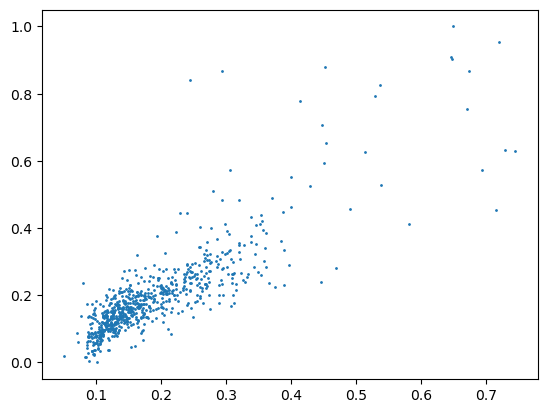

In [2649]:
plt.scatter(ypred,y, s = 1)

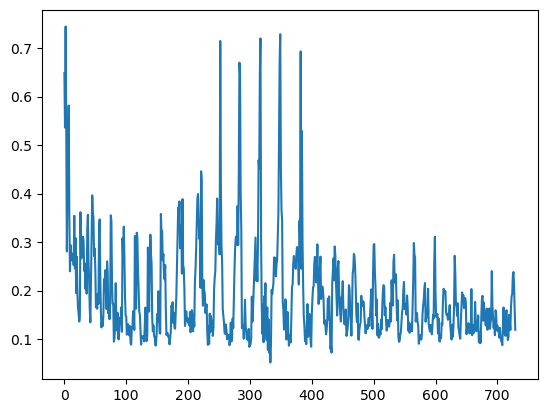

In [2656]:
plt.plot(ypred.T)

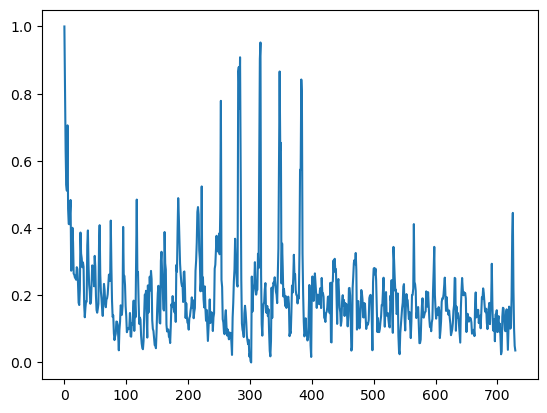

In [2655]:
plt.plot(y.T)

## Regression

https://github.com/PacktPublishing/Hands-On-Graph-Neural-Networks-Using-Python/blob/main/Chapter06/chapter6.ipynb


https://arxiv.org/pdf/1909.13021.pdf

 Wikipedia graphs: Wikipedia page-page networks on three topics: chameleons, crocodiles and
squirrels. Nodes represent articles from the English Wikipedia (December 2018), edges reflect
mutual links between them. Node features indicate the presence of particular nouns in the articles
and the average monthly traffic (October 2017 - November 2018). The regression task is to predict
the log average monthly traffic (December 2018)

In [2616]:
from torch_geometric.datasets import WikipediaNetwork
import torch_geometric.transforms as T

dataset = WikipediaNetwork(root=".", name="chameleon", transform = T.RandomNodeSplit(num_val=200, num_test=500))
data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of unique features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Processing...


Dataset: WikipediaNetwork()
-------------------
Number of graphs: 1
Number of nodes: 2277
Number of unique features: 2325
Number of classes: 5

Graph:
------
Edges are directed: True
Graph has isolated nodes: False
Graph has loops: True


Done!


In [2617]:
from torch_geometric.utils import to_networkx
import pygraphviz as pgv

In [14]:
gg = to_networkx(data)

In [26]:
data

Data(x=[2277, 2325], edge_index=[2, 36101], y=[2277], train_mask=[2277], val_mask=[2277], test_mask=[2277])

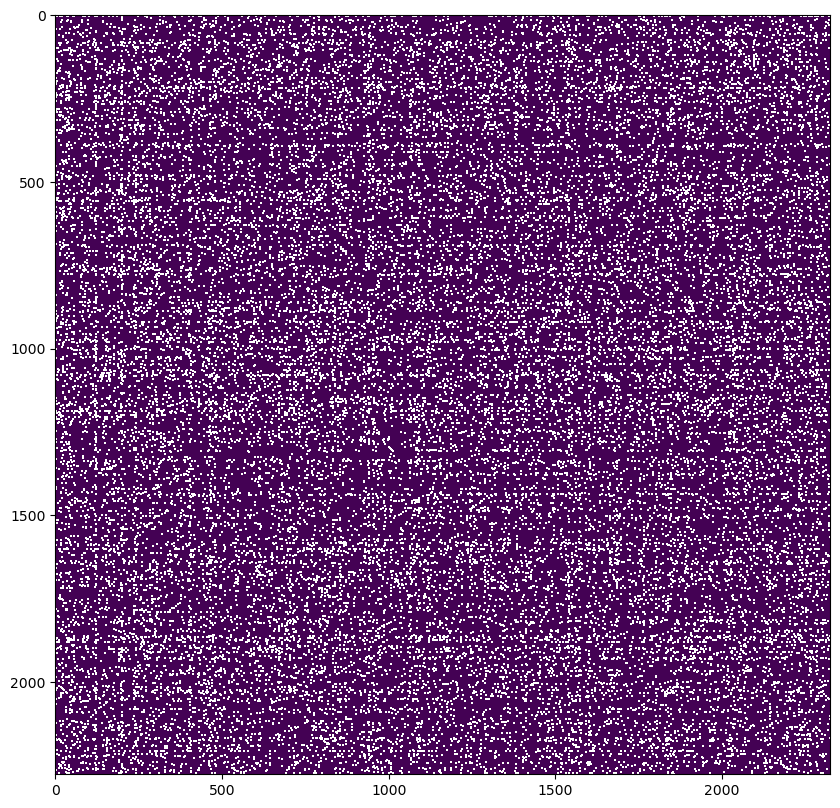

In [46]:
plt.figure(figsize=(10,10))
a = data.x.numpy().astype(np.bool_)
a = np.where(a == True, np.nan, a)
plt.imshow(a)

In [ ]:
import pandas as pd
df = pd.read_csv('wikipedia/chameleon/musae_chameleon_target.csv')

In [40]:
df

,id,target
0,0,171
1,1,8089
2,2,8568
3,3,47178
4,4,3634
...,...,...
2272,2272,31418
2273,2273,2716
2274,2274,99
2275,2275,22898


In [33]:
values = np.log10(df['target'])

In [34]:
data.y = torch.tensor(values)

In [35]:
data.y

tensor([2.2330, 3.9079, 3.9329,  ..., 1.9956, 4.3598, 2.4409],
       dtype=torch.float64)

<BarContainer object of 63 artists>

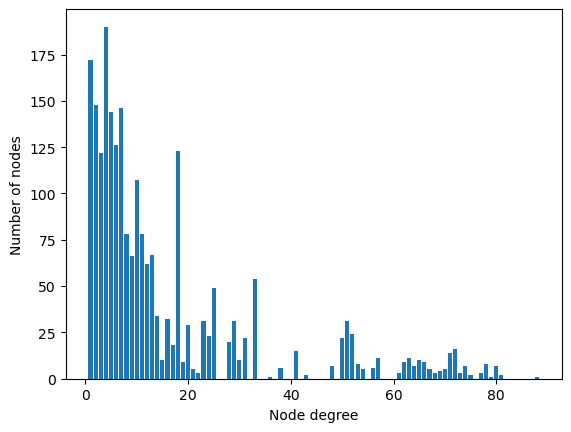

In [36]:
from torch_geometric.utils import degree
from collections import Counter

# Get list of degrees for each node
degrees = degree(data.edge_index[0]).numpy()

# Count the number of nodes for each degree
numbers = Counter(degrees)

# Bar plot
fig, ax = plt.subplots()
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
plt.bar(numbers.keys(), numbers.values())

In [37]:
import seaborn as sns
from scipy.stats import norm

df['target'] = values
fig = sns.distplot(df['target'], fit=norm)

ModuleNotFoundError: No module named 'seaborn'

In [23]:
class GCN(torch.nn.Module):
    """Graph Convolutional Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gcn1 = GCNConv(dim_in, dim_h*4)
        self.gcn2 = GCNConv(dim_h*4, dim_h*2)
        self.gcn3 = GCNConv(dim_h*2, dim_h)
        self.linear = torch.nn.Linear(dim_h, dim_out)

    def forward(self, x, edge_index):
        h = self.gcn1(x, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn2(h, edge_index)
        h = torch.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gcn3(h, edge_index)
        h = torch.relu(h)
        h = self.linear(h)
        return h

    def fit(self, data, epochs): 
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.02,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, data.edge_index)
            print(out.shape)
            loss = F.mse_loss(out.squeeze()[data.train_mask], data.y[data.train_mask].float())
            loss.backward()
            optimizer.step()
            if epoch % 20 == 0:
                val_loss = F.mse_loss(out.squeeze()[data.val_mask], data.y[data.val_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.5f} | Val Loss: {val_loss:.5f}")

    def test(self, data):
        self.eval()
        out = self(data.x, data.edge_index)
        return F.mse_loss(out.squeeze()[data.test_mask], data.y[data.test_mask].float())

# Create the Vanilla GNN model
gcn = GCN(dataset.num_features, 128, 1)
print(gcn) 

GCN(
  (gcn1): GCNConv(2325, 512)
  (gcn2): GCNConv(512, 256)
  (gcn3): GCNConv(256, 128)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


In [24]:
# Train
gcn.fit(data, epochs=2)

# Test
loss = gcn.test(data)
print(f'\nGCN test loss: {loss:.5f}\n')

torch.Size([2277, 1])
Epoch   0 | Train Loss: 5.99762 | Val Loss: 5.67242
torch.Size([2277, 1])
torch.Size([2277, 1])

GCN test loss: 5.99210



## GraphSAGE

https://github.com/
PacktPublishing/Hands-On-Graph-Neural-Networks-Using-Python/tree/
main/Chapter08

# Temporal Graph Neural Network

https://github.com/PacktPublishing/Hands-On-Graph-Neural-Networks-Using-Python/tree/main/Chapter13

In [587]:
from torch_geometric_temporal.signal import temporal_signal_split
from torch_geometric_temporal.dataset import WikiMathsDatasetLoader
from torch_geometric_temporal.nn.recurrent import EvolveGCNH

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [589]:
dataset = WikiMathsDatasetLoader().get_dataset()

In [595]:
dataset

In [ ]:
train_dataset, test_dataset = temporal_signal_split(dataset, train_ratio=0.5)

mean_cases = [snapshot.y.mean().item() for snapshot in dataset]
std_cases = [snapshot.y.std().item() for snapshot in dataset]
df = pd.DataFrame(mean_cases, columns=['mean'])
df['std'] = pd.DataFrame(std_cases, columns=['std'])
df['rolling'] = df['mean'].rolling(7).mean()
                         
plt.figure(figsize=(10,5))
plt.plot(df['mean'], 'k-', label='Mean')
plt.plot(df['rolling'], 'g-', label='Moving average')
plt.grid(linestyle=':')
plt.fill_between(df.index, df['mean']-df['std'], df['mean']+df['std'], color='r', alpha=0.1)
plt.axvline(x=360, color='b', linestyle='--')
plt.text(360, 1.5, 'Train/test split', rotation=-90, color='b')
plt.xlabel('Time (days)')
plt.ylabel('Normalized number of visits')
plt.legend(loc='upper right') 

In [6]:
train_dataset[0]

Data(x=[1068, 8], edge_index=[2, 27079], edge_attr=[27079], y=[1068])

In [61]:
import torch
torch.manual_seed(0)

class TemporalGNN(torch.nn.Module):
    def __init__(self, node_count, dim_in):
        super().__init__()
        self.recurrent = EvolveGCNH(node_count, dim_in)
        self.linear = torch.nn.Linear(dim_in, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.recurrent(x, edge_index, edge_weight).relu()
        h = self.linear(h)
        return h

model = TemporalGNN(dataset[0].x.shape[0], 
                    dataset[0].x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()

TemporalGNN(
  (recurrent): EvolveGCNH(
    (pooling_layer): TopKPooling(8, ratio=0.00749063670411985, multiplier=1.0)
    (recurrent_layer): GRU(8, 8)
    (conv_layer): GCNConv_Fixed_W(8, 8)
  )
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
# Training
for epoch in tqdm(range(50)):
    for i, snapshot in enumerate(train_dataset):
        y_pred = model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
        loss = torch.mean((y_pred-snapshot.y)**2)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

# Evaluation
model.eval()
loss = 0
for i, snapshot in enumerate(test_dataset):
    y_pred = model(snapshot.x, snapshot.edge_index, snapshot.edge_attr)
    mse = torch.mean((y_pred-snapshot.y)**2)
    loss += mse
loss = loss / (i+1)
print(f'MSE = {loss.item():.4f}')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:59<00:00,  2.39s/it]


In [ ]:
y_preds = [model(snapshot.x, snapshot.edge_index, snapshot.edge_attr).squeeze().detach().numpy().mean() for snapshot in test_dataset]

plt.figure(figsize=(10,5), dpi=300)
plt.plot(df['mean'], 'k-', label='Mean')
plt.plot(df['rolling'], 'g-', label='Moving average')
plt.plot(range(360,722), y_preds, 'r-', label='Prediction')
plt.grid(linestyle=':')
plt.fill_between(df.index, df['mean']-df['std'], df['mean']+df['std'], color='r', alpha=0.1)
plt.axvline(x=360, color='b', linestyle='--')
plt.text(360, 1.5, 'Train/test split', rotation=-90, color='b')
plt.xlabel('Time (days)')
plt.ylabel('Normalized number of visits')
plt.legend(loc='upper right')

In [ ]:
from torch_geometric_temporal.nn.recurrent import EvolveGCNO

class TemporalGNN(torch.nn.Module):
    def __init__(self, dim_in):
        super().__init__()
        self.recurrent = EvolveGCNO(dim_in, 1)
        self.linear = torch.nn.Linear(dim_in, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.recurrent(x, edge_index, edge_weight).relu()
        h = self.linear(h)
        return h

model = TemporalGNN(dataset[0].x.shape[1])